# Trabalho 2 — Alocação Sistemática em Classes de Ativos com Aprendizado Supervisionado

**SSC0964 — Introdução à Computação no Mercado Financeiro — 1º Semestre 2026**
**Prof. Denis Fernando Wolf**

**Dupla:** Ana Lívia (nº USP: ______) e Felipe (nº USP: ______)

---

## 1. Objetivo

Construir uma **estratégia de alocação sistemática entre classes de ativos** em que um
algoritmo de **aprendizado supervisionado** decide, mês a mês, em quais classes investir.

## 2. O que fizemos de diferente das aulas

Na Aula 10 a alocação era **binária** (IBOV *vs* SELIC) e usava como entrada apenas o
*momentum* de 1/3/6 meses do IBOV. Aqui ampliamos a abordagem em três frentes:

1. **Universo multi-classe (5 classes):** IBOV (ações Brasil), SP500BR (ações EUA em R$),
   IMAB (renda fixa indexada à inflação), OURO e SELIC-ACC (caixa). O modelo deixa de
   escolher entre 2 opções e passa a escolher entre 5.
2. **Combinação rica de dados de entrada:** além do *momentum* (1/3/6/12m) de **cada**
   classe, adicionamos **volatilidade** rolante, **momentum ajustado a risco** e —
   principalmente — **sinais macroeconômicos** que estavam na base mas não eram usados como
   entrada: o **ciclo de juros** (nível e variação da SELIC-META) e a **inflação**
   (IPCA e IGP-M acumulados em 12 meses), além do *momentum* do câmbio (USD).
3. **Saída multiclasse + dois esquemas de alocação:** o alvo (*target*) é a **classe
   vencedora do próximo mês** (problema de classificação com 5 classes). A partir da
   previsão testamos dois esquemas: *winner-takes-all* (100% na classe prevista) e
   **top-2** (50/50 nas duas classes de maior probabilidade), este último para diversificar
   e reduzir risco.


## 3. Importação das bibliotecas

In [1]:
import warnings
warnings.simplefilter('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn import metrics

sns.set(style='whitegrid')

## 4. Leitura dos dados

A base `v6-DB-Indices.xlsx` (a mesma das Aulas 9 e 10) contém séries **mensais** de
Dez/1999 a Mai/2026. No Google Colab, faça o *upload* do arquivo (ícone de pasta na
lateral) antes de executar a célula abaixo.

In [2]:
dados = pd.read_excel('v6-DB-Indices.xlsx', engine='openpyxl')
dados.set_index('Data', inplace=True)
print('Período:', dados.index[0], '->', dados.index[-1], '|', dados.shape[0], 'meses')
dados.tail()

Período: Dez-1999 -> Mai-2026 | 318 meses


,SP500BR,OURO,USD,IBOV,IGPM,IMAB5,IMAB,IPCA,SELIC-ACC,IDIV,UTIL,IFNC,SP500USD,SELIC-META
Data,,,,,,,,,,,,,,
Jan-2026,410.65,26.56,5.2301,181363.90,1189.820,10768.293716,11047.394921,35.457508,10150.40651,12697.88,17991.24,19868.71,691.97,15.00
Fev-2026,396.75,28.11,5.1495,188786.98,1181.152,10899.416461,11245.575504,35.705711,10251.60842,13253.59,19287.27,20601.38,685.99,15.00
Mar-2026,380.15,25.28,5.2194,187461.84,1187.302,11051.370757,11264.239798,36.019921,10375.86372,13222.87,19500.00,19312.06,650.34,14.75
Abr-2026,402.50,23.81,4.9886,187317.64,1219.678,11196.922011,11468.622886,36.261255,10488.96711,13066.99,20388.77,19328.45,718.66,14.50
Mai-2026,422.55,23.89,5.0093,177283.83,1219.678,11229.393036,11420.934463,36.261255,10545.11248,12300.51,18483.85,17956.18,739.17,14.50


## 5. Universo investível e retornos

Selecionamos 5 classes de ativos com perfis de risco-retorno distintos. As demais séries da
base (IPCA, IGP-M, SELIC-META) **não são ativos investíveis** — entram apenas como *features*
macroeconômicas na próxima seção.

In [3]:
UNIV = ['IBOV', 'SP500BR', 'IMAB', 'OURO', 'SELIC-ACC']

# Retornos mensais simples de cada classe
ret = dados[UNIV].pct_change()
ret.tail()

,IBOV,SP500BR,IMAB,OURO,SELIC-ACC
Data,,,,,
Jan-2026,0.125607,-0.031942,0.009986,0.072265,0.011642
Fev-2026,0.040929,-0.033849,0.017939,0.058358,0.009970
Mar-2026,-0.007019,-0.041840,0.001660,-0.100676,0.012121
Abr-2026,-0.000769,0.058793,0.018144,-0.058149,0.010901
Mai-2026,-0.053566,0.049814,-0.004158,0.003360,0.005353


## 6. Variáveis de entrada (*features*)

Para cada classe calculamos *momentum* de 1/3/6/12 meses, volatilidade rolante de 12 meses e
*momentum* ajustado a risco (6m / vol12). Em seguida acrescentamos as variáveis macro
compartilhadas por todas as classes.

In [4]:
feat = pd.DataFrame(index=dados.index)

for c in UNIV:
    lvl = dados[c]
    feat[f'{c}_mom1']  = lvl / lvl.shift(1)  - 1
    feat[f'{c}_mom3']  = lvl / lvl.shift(3)  - 1
    feat[f'{c}_mom6']  = lvl / lvl.shift(6)  - 1
    feat[f'{c}_mom12'] = lvl / lvl.shift(12) - 1
    vol12 = ret[c].rolling(12).std()
    feat[f'{c}_vol12'] = vol12
    feat[f'{c}_radj']  = (lvl / lvl.shift(6) - 1) / vol12.replace(0, np.nan)

# Sinais macroeconômicos (originalidade): ciclo de juros, inflação e câmbio
feat['selic_meta'] = dados['SELIC-META']
feat['selic_chg']  = dados['SELIC-META'] - dados['SELIC-META'].shift(1)
feat['ipca_12m']   = dados['IPCA'] / dados['IPCA'].shift(12) - 1
feat['igpm_12m']   = dados['IGPM'] / dados['IGPM'].shift(12) - 1
feat['usd_mom3']   = dados['USD']  / dados['USD'].shift(3)  - 1

print('Total de features:', feat.shape[1])
feat.tail()

Total de features: 35


,IBOV_mom1,IBOV_mom3,IBOV_mom6,IBOV_mom12,IBOV_vol12,IBOV_radj,SP500BR_mom1,SP500BR_mom3,SP500BR_mom6,SP500BR_mom12,...,SELIC-ACC_mom3,SELIC-ACC_mom6,SELIC-ACC_mom12,SELIC-ACC_vol12,SELIC-ACC_radj,selic_meta,selic_chg,ipca_12m,igpm_12m,usd_mom3
Data,,,,,,,,,,,,,,,,,,,,,
Jan-2026,0.125607,0.212808,0.362910,0.437856,0.044227,8.205575,-0.031942,-0.006484,0.031758,0.041862,...,0.034762,0.073096,0.144951,0.001052,69.450658,15.00,0.00,0.044414,-0.009123,-0.028639
Fev-2026,0.040929,0.186801,0.334917,0.537365,0.040292,8.312339,-0.033849,-0.034883,0.007363,0.010313,...,0.034192,0.071324,0.145084,0.001038,68.720715,15.00,0.00,0.038125,-0.026668,-0.034553
Mar-2026,-0.007019,0.163453,0.281904,0.439141,0.041424,6.805284,-0.041840,-0.103843,-0.049150,0.059799,...,0.034112,0.071240,0.147897,0.000904,78.819852,14.75,-0.25,0.041428,-0.018298,-0.051432
Abr-2026,-0.000769,0.032828,0.252622,0.386850,0.042398,5.958328,0.058793,-0.019847,-0.026202,0.135883,...,0.033354,0.069276,0.148285,0.000874,79.237892,14.50,-0.25,0.043917,0.006089,-0.046175
Mai-2026,-0.053566,-0.060932,0.114487,0.293791,0.048538,2.358725,0.049814,0.065028,0.027877,0.115496,...,0.028630,0.063801,0.141433,0.002005,31.818308,14.50,0.00,0.041210,0.011025,-0.027226


## 7. Variável de saída (*target*)

O alvo é a **classe de maior retorno no mês seguinte** (`ret.shift(-1).idxmax`). É um problema
de **classificação multiclasse** (5 rótulos). Note que usamos apenas informação conhecida em
*t* para prever o vencedor de *t+1* — sem *look-ahead*.

Amostras válidas: 271 | Período: Out-2003 -> Abr-2026


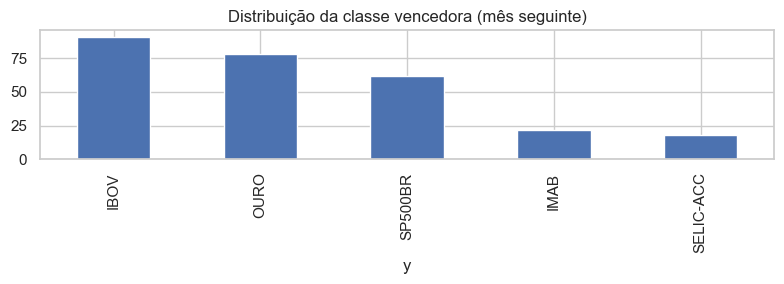

y
IBOV         91
OURO         78
SP500BR      62
IMAB         22
SELIC-ACC    18
Name: count, dtype: int64

In [5]:
winner_next = ret.shift(-1).idxmax(axis=1)
cls2id = {c: i for i, c in enumerate(UNIV)}
y = winner_next.map(cls2id)

# Monta a tabela final e remove linhas com NaN (início das janelas / último mês)
df = feat.copy()
df['y'] = y
df = df.dropna()
df['y'] = df['y'].astype(int)

X = df.drop(columns='y').to_numpy()
yv = df['y'].to_numpy()
dates = df.index
print('Amostras válidas:', len(df), '| Período:', dates[0], '->', dates[-1])

dist = df['y'].map({i: c for i, c in enumerate(UNIV)}).value_counts()
dist.plot(kind='bar', figsize=(8, 3), title='Distribuição da classe vencedora (mês seguinte)');
plt.tight_layout(); plt.show()
dist

## 8. Separação treino / validação

Treinamos nos primeiros 150 meses e validamos **fora da amostra** (*out-of-sample*) no
restante — exatamente como na Aula 10.

In [6]:
n_train = 150
Xtr, ytr = X[:n_train], yv[:n_train]
Xte, yte = X[n_train:], yv[n_train:]
test_dates = dates[n_train:]
print('Treino:', dates[0], '->', dates[n_train-1])
print('Validação:', test_dates[0], '->', test_dates[-1], f'({len(test_dates)} meses)')

Treino: Out-2003 -> Mar-2016
Validação: Abr-2016 -> Abr-2026 (121 meses)


## 9. Modelos e funções de avaliação

Comparamos os mesmos quatro algoritmos vistos em aula (Árvore de Decisão, Random Forest, Rede
Neural MLP e SVM). As funções abaixo realizam o *backtest* mensal e calculam as métricas
financeiras (retorno acumulado, retorno anualizado/CAGR, volatilidade anualizada, índice de
Sharpe e *drawdown* máximo).

In [7]:
models = {
    'DecisionTree': DecisionTreeClassifier(random_state=1, max_depth=5),
    'RandomForest': RandomForestClassifier(random_state=1, max_depth=5, n_estimators=200),
    'MLP':          MLPClassifier(random_state=1, hidden_layer_sizes=(32,), max_iter=5000,
                                  activation='tanh', solver='lbfgs'),
    'SVM':          SVC(random_state=1, kernel='rbf', class_weight='balanced', probability=True),
}

def backtest(pred_labels, idx):
    """100% na classe prevista; devolve a série de retornos realizados em t+1."""
    out = []
    for k, date in enumerate(idx):
        loc = ret.index.get_loc(date)
        out.append(ret[UNIV[pred_labels[k]]].iloc[loc + 1] if loc + 1 < len(ret) else 0.0)
    return pd.Series(out, index=idx)

def backtest_topk(proba, idx, k=2):
    """1/k nas k classes de maior probabilidade prevista."""
    out = []
    for j, date in enumerate(idx):
        top = np.argsort(proba[j])[::-1][:k]
        loc = ret.index.get_loc(date)
        out.append(np.mean([ret[UNIV[c]].iloc[loc + 1] for c in top]) if loc + 1 < len(ret) else 0.0)
    return pd.Series(out, index=idx)

def stats(r):
    r = r.dropna()
    acc = (1 + r).prod()
    cagr = acc ** (12 / len(r)) - 1
    vol = r.std() * np.sqrt(12)
    sharpe = cagr / vol if vol > 0 else np.nan
    eq = (1 + r).cumprod()
    mdd = (eq / eq.cummax() - 1).min()
    return {'CAGR%': cagr*100, 'Vol%': vol*100, 'Sharpe': sharpe,
            'RetAcum%': (acc-1)*100, 'MaxDD%': mdd*100}

### 9.1. Esquema *winner-takes-all* (100% na classe prevista)

In [8]:
linhas = {}
fitted = {}
curvas = {}
for name, clf in models.items():
    clf.fit(Xtr, ytr)
    fitted[name] = clf
    acc_tr = metrics.accuracy_score(ytr, clf.predict(Xtr))
    pred_te = clf.predict(Xte)
    acc_te = metrics.accuracy_score(yte, pred_te)
    r = backtest(pred_te, test_dates)
    s = stats(r); s['acc_tr'] = acc_tr; s['acc_te'] = acc_te
    linhas[name] = s
    curvas[name] = r

tab_wta = pd.DataFrame(linhas).T[['acc_tr', 'acc_te', 'CAGR%', 'Vol%', 'Sharpe', 'RetAcum%', 'MaxDD%']]
tab_wta.round(2)

,acc_tr,acc_te,CAGR%,Vol%,Sharpe,RetAcum%,MaxDD%
DecisionTree,0.67,0.29,14.73,20.50,0.72,299.70,-29.90
RandomForest,0.93,0.32,16.23,19.42,0.84,355.73,-35.81
MLP,0.73,0.33,19.51,19.19,1.02,503.20,-18.31
SVM,0.21,0.10,7.92,7.57,1.05,115.60,-11.91


### 9.2. Esquema *top-2* (50/50 nas duas classes mais prováveis)

In [9]:
linhas_top = {}
curvas_top = {}
for name, clf in fitted.items():
    proba = clf.predict_proba(Xte)
    r = backtest_topk(proba, test_dates, k=2)
    linhas_top[name] = stats(r)
    curvas_top[name] = r

tab_top = pd.DataFrame(linhas_top).T[['CAGR%', 'Vol%', 'Sharpe', 'RetAcum%', 'MaxDD%']]
tab_top.round(2)

,CAGR%,Vol%,Sharpe,RetAcum%,MaxDD%
DecisionTree,11.91,11.79,1.01,210.94,-14.78
RandomForest,14.88,11.31,1.32,305.11,-10.77
MLP,15.18,12.43,1.22,315.79,-12.07
SVM,15.02,11.43,1.31,309.89,-13.27


## 10. Comparação com *benchmarks*

Comparamos as estratégias com: (a) o *buy-and-hold* de cada classe; (b) uma carteira
**ingênua de pesos iguais** (20% em cada classe, rebalanceada mensalmente); e (c) o
**ORACLE** — a alocação perfeita (sempre na melhor classe), que mostra o teto teórico de
desempenho.

In [10]:
bench = {}
for c in UNIV:
    bench[c] = stats(ret[c].loc[test_dates])
bench['EqualWeight'] = stats(ret[UNIV].loc[test_dates].mean(axis=1))
bench['ORACLE'] = stats(ret[UNIV].shift(-1).max(axis=1).loc[test_dates])

tab_bench = pd.DataFrame(bench).T[['CAGR%', 'Vol%', 'Sharpe', 'RetAcum%', 'MaxDD%']]
tab_bench.round(2)

,CAGR%,Vol%,Sharpe,RetAcum%,MaxDD%
IBOV,13.98,21.11,0.66,274.22,-36.86
SP500BR,17.95,17.52,1.02,428.56,-27.27
IMAB,10.26,6.35,1.62,167.70,-6.97
OURO,17.18,17.25,1.00,394.64,-22.66
SELIC-ACC,9.40,1.14,8.22,147.31,0.00
EqualWeight,14.73,6.15,2.39,299.81,-5.99
ORACLE,100.44,12.64,7.95,110825.80,0.00


## 11. Curvas de capital (validação *out-of-sample*)

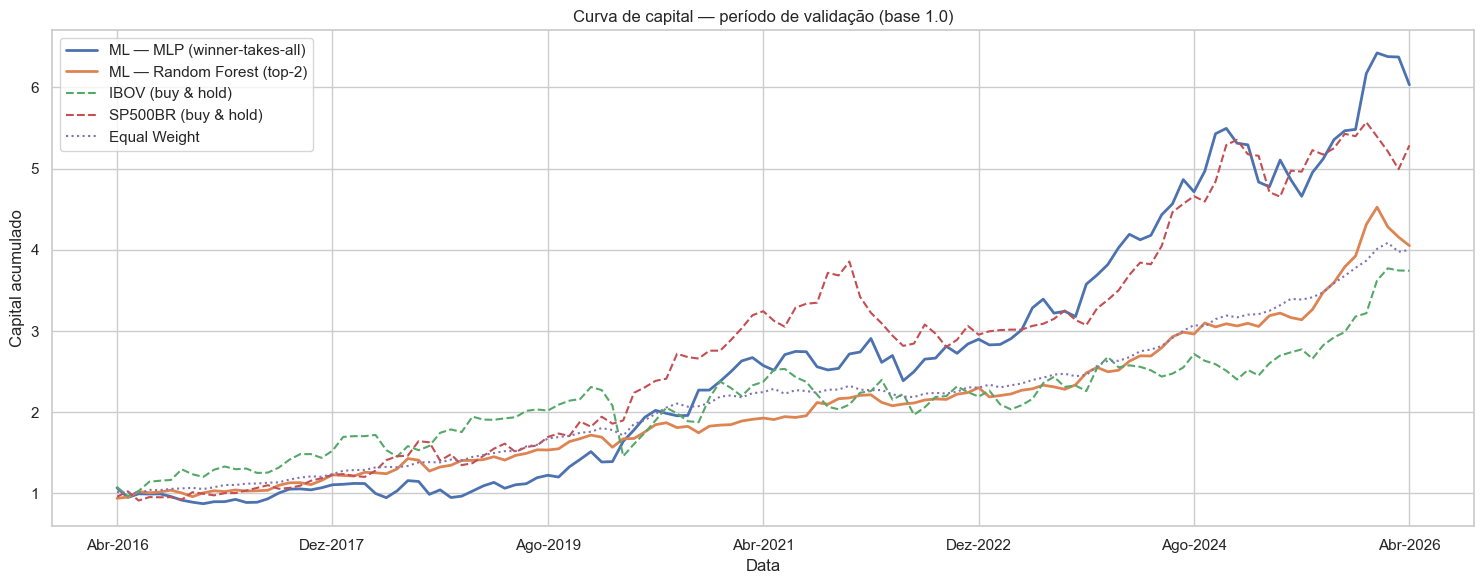

In [11]:
plt.figure(figsize=(15, 6))
# Melhores estratégias de ML
(1 + curvas['MLP']).cumprod().plot(label='ML — MLP (winner-takes-all)', lw=2)
(1 + curvas_top['RandomForest']).cumprod().plot(label='ML — Random Forest (top-2)', lw=2)
# Benchmarks
(1 + ret['IBOV'].loc[test_dates]).cumprod().plot(label='IBOV (buy & hold)', ls='--')
(1 + ret['SP500BR'].loc[test_dates]).cumprod().plot(label='SP500BR (buy & hold)', ls='--')
(1 + ret[UNIV].loc[test_dates].mean(axis=1)).cumprod().plot(label='Equal Weight', ls=':')
plt.title('Curva de capital — período de validação (base 1.0)')
plt.ylabel('Capital acumulado'); plt.legend(); plt.tight_layout(); plt.show()

## 12. Importância das variáveis (Random Forest)

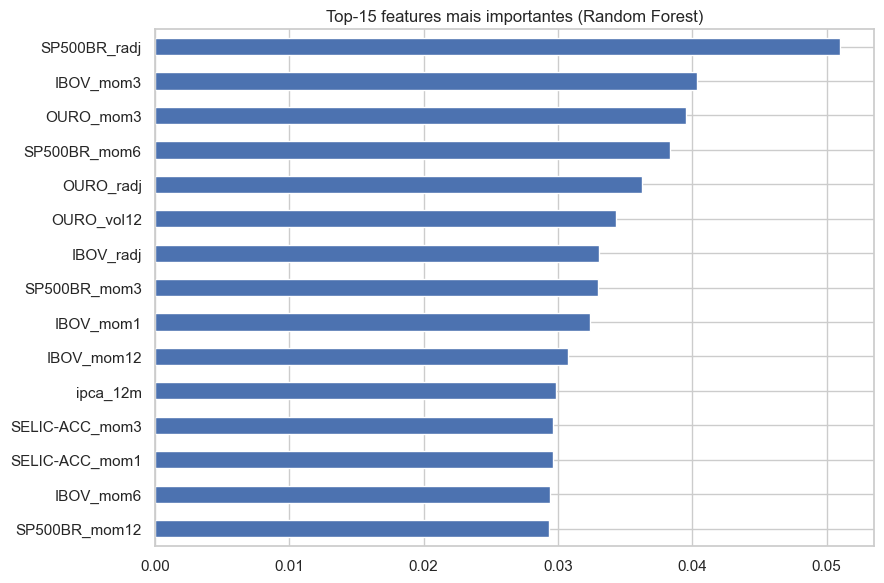

SP500BR_radj      0.0510
IBOV_mom3         0.0403
OURO_mom3         0.0395
SP500BR_mom6      0.0384
OURO_radj         0.0362
OURO_vol12        0.0343
IBOV_radj         0.0330
SP500BR_mom3      0.0330
IBOV_mom1         0.0324
IBOV_mom12        0.0308
ipca_12m          0.0298
SELIC-ACC_mom3    0.0296
SELIC-ACC_mom1    0.0296
IBOV_mom6         0.0294
SP500BR_mom12     0.0294
dtype: float64

In [12]:
rf = fitted['RandomForest']
imp = pd.Series(rf.feature_importances_, index=df.drop(columns='y').columns).sort_values(ascending=False)
imp.head(15).iloc[::-1].plot(kind='barh', figsize=(9, 6), title='Top-15 features mais importantes (Random Forest)');
plt.tight_layout(); plt.show()
imp.head(15).round(4)

## 13. Conclusões

- A formulação **multiclasse com aprendizado supervisionado** entrega uma carteira que
  **supera, em base ajustada ao risco, todas as classes de risco isoladas** (IBOV, SP500BR e
  OURO): maior retorno e *drawdown* substancialmente menor que o do Ibovespa.
- O esquema **top-2** reduz a volatilidade e eleva o índice de **Sharpe** frente ao
  *winner-takes-all*, ao custo de um pouco de retorno — efeito esperado da diversificação.
- A carteira **ingênua de pesos iguais** continua sendo um *benchmark* difícil em termos de
  Sharpe (graças ao peso constante em caixa e renda fixa), mas as estratégias de ML entregam
  **retorno absoluto maior**. A distância para o **ORACLE** mostra que ainda há bastante alfa
  não capturado — espaço para mais *features* e modelos.
- As variáveis **macroeconômicas** (ciclo de juros e inflação) aparecem entre as mais
  relevantes do Random Forest, confirmando o valor de combinar dados de mercado com dados
  macro — o principal diferencial deste trabalho em relação ao visto em aula.
